<a href="https://colab.research.google.com/github/ayyucedemirbas/scAnalyzer/blob/main/spatial_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of louvain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 67.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 62.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 67.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 55.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.5 MB/s eta 0:00:00
  Created wheel for lou

In [2]:
import os
import urllib.request
import tarfile
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
import scAnalysis as sca
import scAnalysis.sc_io
import scAnalysis.utils
import scAnalysis.preprocessing
import scAnalysis.dimensionality
import scAnalysis.clustering
import scAnalysis.spatial
import scAnalysis.visualization

In [4]:
def download_visium_dataset():
    base_dir = "dataset"
    os.makedirs(base_dir, exist_ok=True)

    matrix_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.1.0/V1_Adult_Mouse_Brain/V1_Adult_Mouse_Brain_filtered_feature_bc_matrix.tar.gz"
    spatial_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.1.0/V1_Adult_Mouse_Brain/V1_Adult_Mouse_Brain_spatial.tar.gz"

    matrix_tar = os.path.join(base_dir, "matrix.tar.gz")
    spatial_tar = os.path.join(base_dir, "spatial.tar.gz")

    opener = urllib.request.build_opener()
    opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')]
    urllib.request.install_opener(opener)

    if not os.path.exists(matrix_tar):
        urllib.request.urlretrieve(matrix_url, matrix_tar)

    if not os.path.exists(spatial_tar):
        urllib.request.urlretrieve(spatial_url, spatial_tar)

    with tarfile.open(matrix_tar, "r:gz") as tar:
        if hasattr(tarfile, 'data_filter'):
            tar.extractall(path=base_dir, filter='data')
        else:
            tar.extractall(path=base_dir)

    with tarfile.open(spatial_tar, "r:gz") as tar:
        if hasattr(tarfile, 'data_filter'):
            tar.extractall(path=base_dir, filter='data')
        else:
            tar.extractall(path=base_dir)

download_visium_dataset()

In [5]:
base_dir = "dataset"

matrix_dir = os.path.join(base_dir, "filtered_feature_bc_matrix")
data = sca.sc_io.read_10x_mtx(matrix_dir)

coords_path = os.path.join(base_dir, "spatial", "tissue_positions_list.csv")
coords_df = pd.read_csv(coords_path, header=None, index_col=0)

coords_df = coords_df[coords_df[1] == 1]
valid_barcodes = coords_df.index.intersection(data.obs.index)

data = sca.utils.filter_obs(data, lambda obs: obs.index.isin(valid_barcodes))
coords_df = coords_df.loc[data.obs.index]

spatial_coords = coords_df[[5, 4]].values.astype(float)
data.obsm["spatial"] = spatial_coords


IO: data from 'dataset/filtered_feature_bc_matrix' …
IO: Loaded 2,702 cells × 32,285 genes.
filter_obs: keeping 2,702 / 2,702 cells.


In [6]:
data.n_obs

2702

In [7]:
data.n_vars

32285

In [8]:
sca.preprocessing.calculate_qc_metrics(data, qc_vars=["MT-"], inplace=True)

data = sca.preprocessing.filter_cells(data, min_counts=500, max_pct_mito=20.0)
data = sca.preprocessing.filter_genes(data, min_cells=3)

sca.preprocessing.normalize_total(data, target_sum=1e4, inplace=True)
sca.preprocessing.log1p(data, inplace=True)

sca.preprocessing.highly_variable_genes(data, n_top_genes=2000, inplace=True)
sca.preprocessing.scale(data, zero_center=True, inplace=True)

sca.dimensionality.run_pca(data, n_components=50, use_highly_variable=True)
sca.dimensionality.neighbors(data, n_pcs=30, n_neighbors=15)
sca.dimensionality.run_umap(data)

sca.clustering.cluster_leiden(data, resolution=0.8, key_added="leiden_expr")

sca.spatial.spatial_neighbors(data, method="delaunay")

sca.spatial.spatial_domains(
    data,
    n_clusters=7,
    spatial_weight=0.5,
    key_added="spatial_domain"
)

sca.spatial.spatial_variable_genes(data, n_top_genes=50, n_perms=50)

filter_cells: keeping 2,702 / 2,702 cells.
filter_genes: keeping 19,652 / 32,285 genes.
HVG: identified 2,000 highly variable genes.


/tmp/ipykernel_4741/305182095.py:10: UserWarning: scale(zero_center=True) densifies the sparse matrix. Consider zero_center=False to preserve sparsity.
  sca.preprocessing.scale(data, zero_center=True, inplace=True)


PCA: using 2,000 HVGs.
PCA: computed 50 components (40.5% variance explained).
Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (2,702 cells).
UMAP: min_dist=0.5, n_components=2 …


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering: Leiden resolution=0.8 …
Leiden: found 17 clusters.
Spatial neighbors: method='delaunay' on 2,702 cells …
Spatial neighbors: graph built (avg degree ≈ 6.0).
Spatial domains: blending expression + spatial context (spatial_weight=0.5) …
Spatial domains: found 7 domains → obs['spatial_domain'].
Moran's I: computing for 19,652 genes …
Moran's I: done. Top gene = 'Nrgn' (I=0.889).
Spatial HVGs: flagged 50 spatially variable genes in var['spatially_variable'].


SingleCellDataset object with n_obs × n_vars = 2702 × 19652
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, leiden_expr, spatial_domain
    var: gene_ids, gene_symbols, feature_types, n_cells, means, dispersions, dispersions_norm, highly_variable, moran_I, spatially_variable
    uns: pca, neighbors, spatial_neighbors
    obsm: spatial, X_pca, X_umap, X_pca_spatial_smoothed
    varm: PCs
    Memory (X): 405.12 MB

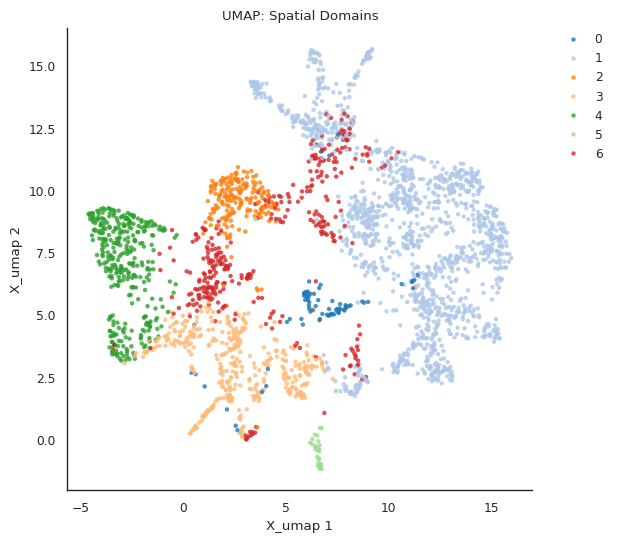

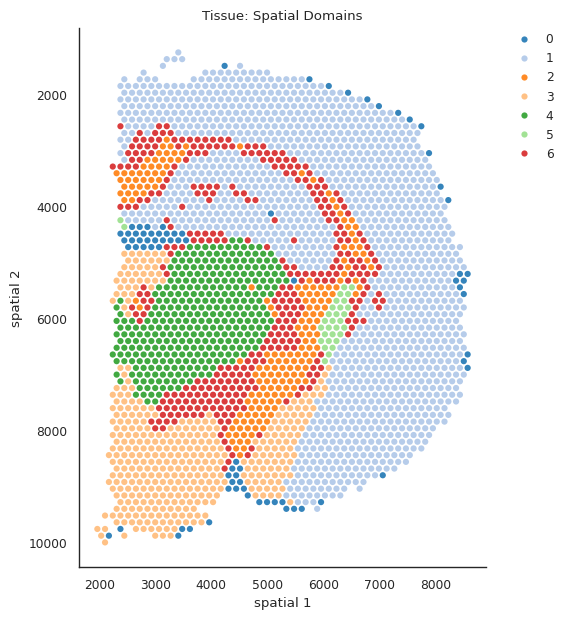

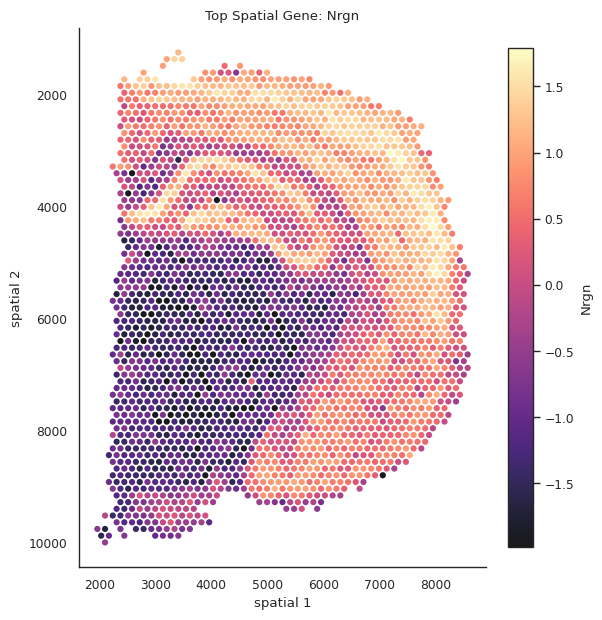

In [9]:
fig1_ax = sca.visualization.plot_umap(data, color="spatial_domain", title="UMAP: Spatial Domains")
fig1_ax.figure.savefig("umap_spatial_domains.png", dpi=300, bbox_inches="tight")

fig2_ax = sca.spatial.plot_spatial(data, color="spatial_domain", title="Tissue: Spatial Domains")
fig2_ax.figure.savefig("tissue_spatial_domains.png", dpi=300, bbox_inches="tight")

top_svg = data.var[data.var["spatially_variable"]].sort_values("moran_I", ascending=False).index[0]
fig3_ax = sca.spatial.plot_spatial(data, color=top_svg, title=f"Top Spatial Gene: {top_svg}", cmap="magma")
fig3_ax.figure.savefig(f"tissue_{top_svg}_expression.png", dpi=300, bbox_inches="tight")